# 201 · Group Sequential Design

Traditional A/B testing requires you to wait until a pre-determined sample size ($N_{fix}$) is reached. **Group Sequential Design (GSD)** allows you to perform "interim looks" and stop early for either success (**Efficacy**) or failure (**Futility**), while strictly controlling the Type I error rate.

In this tutorial, we will:
- Design a Binomial A/B test using the **Lan-DeMets (Spending Function)** approach.
- Visualize the operating characteristics of the design.
- Perform sequential monitoring.
- **Advanced**: Use **Sample Size Re-estimation (SSR)** to adjust the design if the interim result is in the "Promising Zone".

## 1. Setup & Design

We use the `GST_Spending_JennisonTurnbull2000` template. This template encapsulates the complex math of alpha-spending boundaries.

In [1]:
import numpy as np
import ibis
import matplotlib.pyplot as plt
from earlysign.core.ledger import Ledger
from earlysign.schema.ES3.Binomial import ArmData
from earlysign.schema.ES3.GST.Log import DecisionStatus
from earlysign.v1.templates.GST_Spending_JennisonTurnbull2000 import (
    JennisonTurnbull2000Template,
)

ledger = Ledger(ibis.connect("duckdb://:memory:"), "gsd_events").bind(
    exp_id="gsd_tutorial"
)
ledger.ensure()

# 1. Design the protocol
# 5 Looks, O-Brien Fleming boundaries.
trial = JennisonTurnbull2000Template(ledger)
protocol = trial.design(
    p_control=0.10,
    p_treatment=0.12,
    alpha=0.05,
    power=0.8,
    looks=3,
    spending_function="obrien_fleming",
)

print(f"Planned Max N: {int(protocol.method.stopping_policy.timer.max_sample_size)}")

# Initialize random number generator for reproducibility
rng = np.random.default_rng(42)

Planned Max N: 5901


In [2]:
protocol.model_dump()["method"]["stopping_policy"]

{'statistic': {'kind': 'two_arm_binomial_z'},
 'strategy': {'kind': 'alpha_beta_spending',
  'statistical_model': {'kind': 'canonical_gaussian'},
  'alpha_spending_fn': {'family': 'obrien_fleming', 'params': None},
  'beta_spending_fn': {'family': 'obrien_fleming', 'params': None},
  'alpha_budget': 0.05,
  'beta_budget': 0.2,
  'alpha_binding': True,
  'beta_binding': False},
 'timer': {'kind': 'sample_size',
  'unit': <Unit.INDIVIDUALS: 'individuals'>,
  'max_sample_size': 5901},
 'schedule': {'kind': 'fixed',
  'analyses': [0.5217827662802828, 0.7413959046772167, 1.0]},
 'trigger_strategy': {'kind': 'due_look', 'tolerance': 0.0}}

## 2. Visualize Operating Characteristics

Before starting the trial, it is important to check the "Operating Characteristics" (OC) such as the Expected Sample Size (ESS) and Power across different true effect sizes.

,Rel. Lift (%) : (pt - pc) / pc,Power / Rejection Prob,Early Stop Prob,Stop (Efficacy),Stop (Futility),Total ESS,Fixed N (Ref),ESS / Fixed N (%),ESS / Max (%),Max N (Total),Prob > Fixed N
0,-2.000000e+01,0.02%,99.9%,0.0%,100.0%,3088.8,5564.3,55.5%,52.4%,5900.0,0.1%
1,-1.500000e+01,0.06%,99.8%,0.1%,99.9%,3108.3,5564.3,55.9%,52.7%,5900.0,0.2%
2,-1.000000e+01,0.18%,98.9%,0.2%,99.8%,3165.3,5564.3,56.9%,53.6%,5900.0,1.1%
3,-5.000000e+00,1.04%,95.5%,1.0%,99.0%,3308.8,5564.3,59.5%,56.1%,5900.0,4.5%
4,-2.775558e-15,4.88%,89.5%,4.9%,95.1%,3545.7,5564.3,63.7%,60.1%,5900.0,10.5%
5,5.000000e+00,13.86%,82.0%,13.9%,86.1%,3832.4,5564.3,68.9%,65.0%,5900.0,18.0%
6,1.000000e+01,31.22%,73.9%,31.2%,68.8%,4133.1,5564.3,74.3%,70.1%,5900.0,26.1%
7,1.500000e+01,53.70%,71.1%,53.7%,46.3%,4262.3,5564.3,76.6%,72.2%,5900.0,28.9%
8,2.000000e+01,75.96%,76.0%,76.0%,24.0%,4153.6,5564.3,74.6%,70.4%,5900.0,24.0%
9,2.500000e+01,90.12%,85.4%,90.1%,9.9%,3878.2,5564.3,69.7%,65.7%,5900.0,14.6%


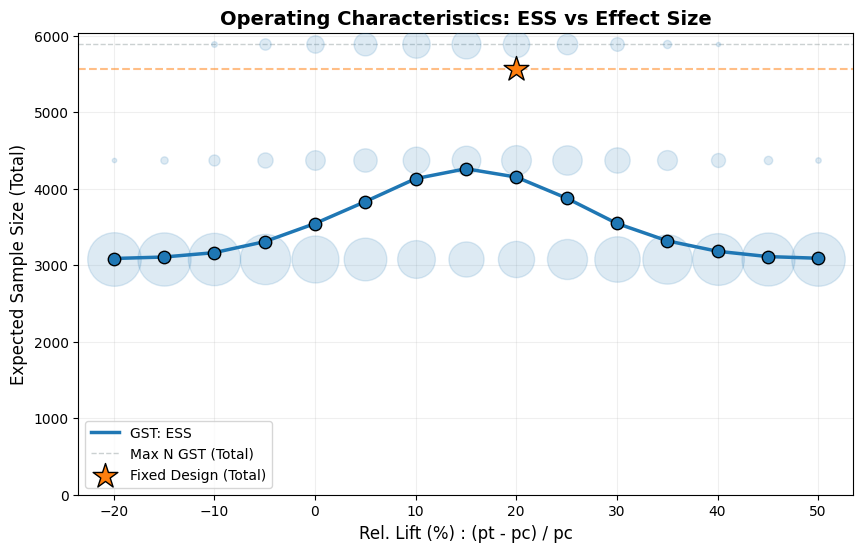

In [3]:
from earlysign.v1.methods.group_sequential.plan.visualize import (
    visualize_protocol_design,
)

# Visualize the design
res = visualize_protocol_design(protocol)
display(res["summary"])
display(res["figure"])

It looks good, so let's use this.

In [4]:
trial.set_protocol(protocol)

## 3. Sequential Monitoring

We simulate data arriving in batches. After each `update()`, we check the progress.

In [5]:
p_c, p_t = 0.10, 0.14  # True effect is larger than designed delta (0.02)
n_per_batch = 200

for iteration in range(1, 15):
    # 1. New data arrives
    batch = [
        ArmData(n=n_per_batch, success=rng.binomial(n_per_batch, p_c), arm="control"),
        ArmData(n=n_per_batch, success=rng.binomial(n_per_batch, p_t), arm="treatment"),
    ]

    # 2. Analyze
    trial.update(batch)

    # 3. Decision Check
    report = trial.report_progress()
    status = report["status"]
    n_curr = report["sample_n"]
    z_curr = report["z_stat"]

    # Milestone logic
    is_milestone = report.get("is_milestone", False)
    next_m = report.get("next_milestone_n")

    if is_milestone:
        trigger_msg = f"[LOOK {report['look']} TRIGGERED]"
    elif next_m is not None:
        trigger_msg = f"(Need {next_m} for next look)"
    else:
        trigger_msg = ""

    print(
        f"Batch {iteration:02d}: N={n_curr}, Z={z_curr:.3f}, Status={status} {trigger_msg}"
    )

    if status != DecisionStatus.CONTINUE_:
        print(f"\n>>> STOP DETERMINED AT N={n_curr}!")
        break

Batch 01: N=400, Z=0.605, Status=continue (Need 3079 for next look)
Batch 02: N=800, Z=0.942, Status=continue (Need 3079 for next look)
Batch 03: N=1200, Z=2.732, Status=continue (Need 3079 for next look)
Batch 04: N=1600, Z=3.017, Status=continue (Need 3079 for next look)
Batch 05: N=2000, Z=3.553, Status=continue (Need 3079 for next look)
Batch 06: N=2400, Z=4.272, Status=continue (Need 3079 for next look)
Batch 07: N=2800, Z=4.619, Status=continue (Need 3079 for next look)
Batch 08: N=3200, Z=4.626, Status=stop_efficacy [LOOK 1 TRIGGERED]

>>> STOP DETERMINED AT N=3200!


## 4. Visualize the Trajectory

Templates provide built-in plotting to visualize the boundaries and the test statistic's path.

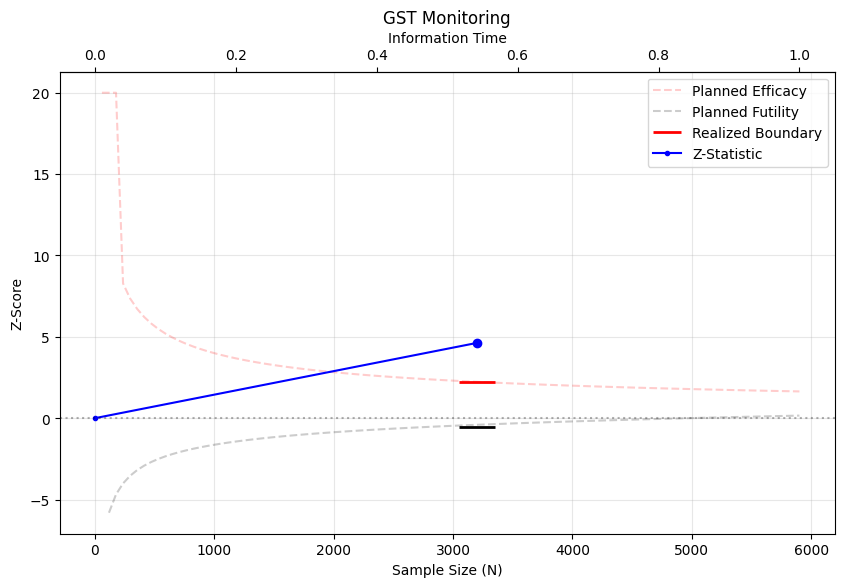

In [6]:
trial.plot_result()
plt.show()

## 5. Advanced: Adaptive SSR (Promising Zone)

What if the interim result is not significant, but "looks promising"? Standard GSD would force you to continue with the original N, potentially under-powering the study if the true effect is smaller than expected.

**Sample Size Re-estimation (SSR)** allows you to increase $N$ at an interim look while preserving the Type I error using the **Cui-Hung-Wang (CHW)** weighted statistic.

In [7]:
from earlysign.v1.templates.GST_PromisingZone_CuiHungWang1999 import (
    CuiHungWang1999Template,
)

ssr_ledger = Ledger(ibis.connect("duckdb://:memory:"), "ssr_events").bind(
    exp_id="ssr_demo"
)
ssr_ledger.ensure()

ssr_trial = CuiHungWang1999Template(ssr_ledger)
ssr_protocol = ssr_trial.design(p_control=0.10, p_treatment=0.11, looks=2)
ssr_trial.set_protocol(ssr_protocol)

print(
    f"Original Max N: {int(ssr_protocol.method.stopping_policy.timer.max_sample_size)}"
)

# 1. Update with 'Promising' but not 'Significant' data
# CP (Conditional Power) will be low enough to justify SSR
mid_batch = [
    ArmData(n=1000, success=100, arm="control"),
    ArmData(n=1000, success=108, arm="treatment"),
]
ssr_trial.update(mid_batch)

final_report = ssr_trial.report_progress()
print(f"Status: {final_report['status']}")
print(f"New Recommended Max N: {final_report['max_sample_size']}")

Original Max N: 22822
Status: continue
New Recommended Max N: 22822


## 6. Summary

- **GSD**: Enables early stopping for efficient resource use.
- **Spending Functions**: Map boundaries to alpha expenditure over time.
- **Adaptive SSR**: Provides a "safety net" to recover power by increasing N in the Promising Zone.

In the next tutorial, we will explore **Anytime Valid Inference**, where we don't even need to pre-specify the number of looks.